## 1. Import Thư viện và Đọc dữ liệu

In [5]:
# Cài đặt thư viện xử lý mất cân bằng dữ liệu (nếu chưa có)
# !pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lý dữ liệu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Mô hình Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Tắt cảnh báo
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc dữ liệu (Đổi tên file cho phù hợp với dữ liệu thực tế)
link='https://drive.google.com/file/d/1Vmvsp_mxgDp1Wi1G64LQ9P9rCpFG70E8/view'
path = 'https://drive.google.com/uc?export=download&id='+link.split('/')[-2]

df = pd.read_csv(path)

## 2. Exploratory Data Analysis (EDA) - Phân tích Khám phá Dữ liệu

In [6]:
# 2.1. Kiểm tra cấu trúc và thông tin cơ bản
display(df.head())
print("-" * 50)
print(df.info())
print("-" * 50)
print("Số lượng giá trị thiếu (NaN) trong mỗi cột:\n", df.isnull().sum())
print("-" * 50)
print("Số lượng hàng trùng lặp:", df.duplicated().sum())


# Thống kê mô tả các biến số học
display(df.describe())

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
--------------------------------------------------
Số lượng giá trị thiếu (NaN) trong mỗi cột:
 customer_id       

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 2.2. Trực quan hóa dữ liệu (Data Visualization)

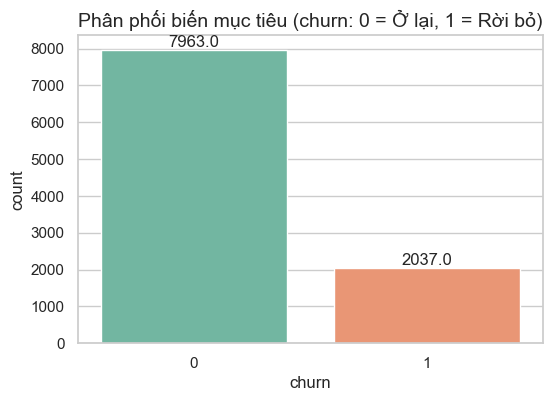

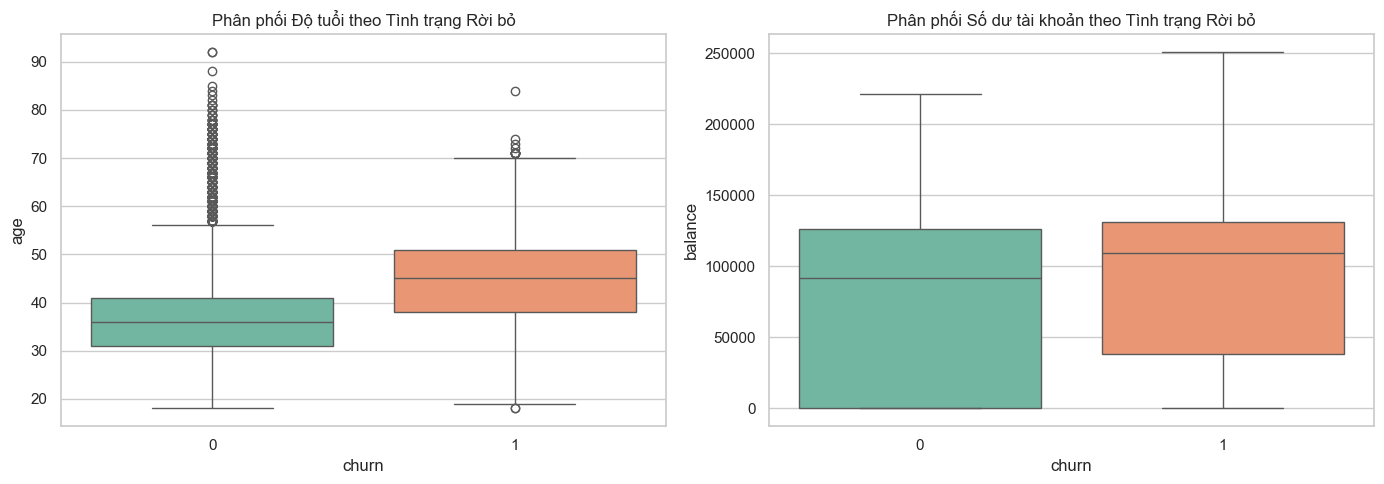

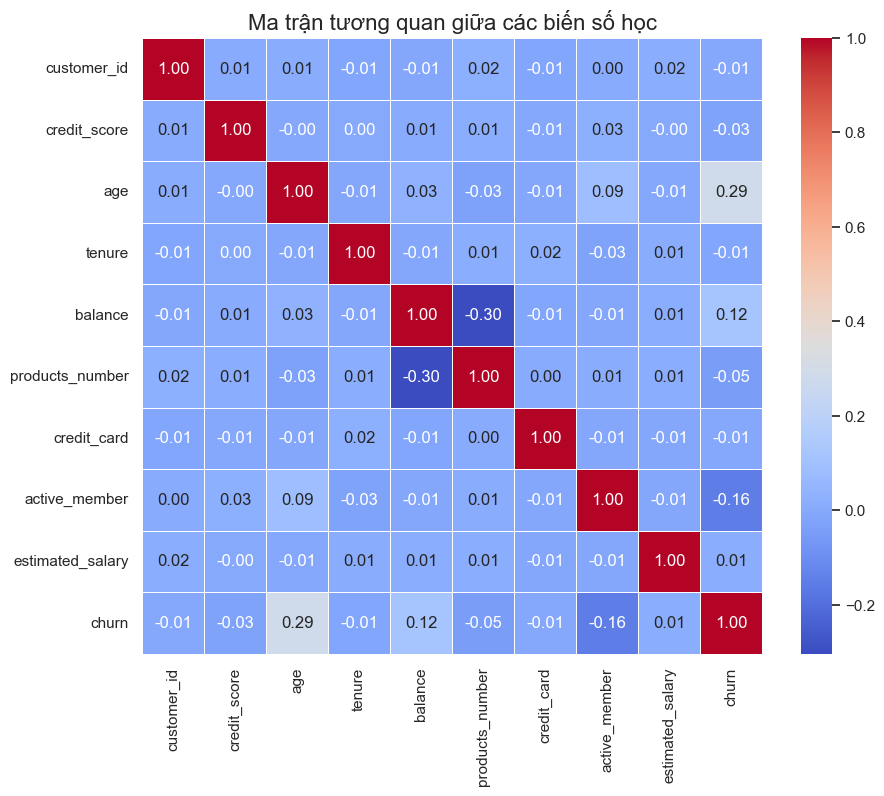

In [7]:
# Tỷ lệ Khách hàng rời bỏ (Biến Target)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Phân phối biến mục tiêu (churn: 0 = Ở lại, 1 = Rời bỏ)', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

# Phân phối Độ tuổi và Số dư tài khoản theo Tình trạng rời bỏ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='churn', y='age', ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối Độ tuổi theo Tình trạng Rời bỏ')

sns.boxplot(data=df, x='churn', y='balance', ax=axes[1], palette='Set2')
axes[1].set_title('Phân phối Số dư tài khoản theo Tình trạng Rời bỏ')
plt.tight_layout()
plt.show()

# Ma trận tương quan (Correlation Heatmap) cho các biến số học
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số học', fontsize=16)
plt.show()

## 3. Data Preprocessing (Tiền Xử Lý Dữ Liệu)
Bước này chuẩn bị dữ liệu thô thành định dạng mà các thuật toán Machine Learning có thể học được.
1. **Encoding:** Biến đổi các cột phân loại (Categorical) thành số.
2. **Train/Test Split:** Chia tách tập huấn luyện và tập kiểm tra.
3. **SMOTE:** Xử lý mất cân bằng dữ liệu trên tập huấn luyện.
4. **Scaling:** Chuẩn hóa các biến số học về cùng thang đo.

In [8]:
# 3.1. Encoding
# Label Encoding cho biến có 2 hạng mục (ví dụ: Gender)
if 'gender' in df.columns:
    le = LabelEncoder()
    df['gender'] = le.fit_transform(df['gender'])

# One-Hot Encoding cho biến có > 2 hạng mục (ví dụ: Geography)
df = pd.get_dummies(df, drop_first=True)

# 3.2. Train/Test Split
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3.3. Xử lý mất cân bằng dữ liệu (SMOTE) chỉ trên tập Train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Số lượng sample trước SMOTE: {len(y_train)}, sau SMOTE: {len(y_train_smote)}")
print("Phân phối y_train_smote:\n", y_train_smote.value_counts())

# 3.4. Scaling (Chuẩn hóa)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Số lượng sample trước SMOTE: 7000, sau SMOTE: 11148
Phân phối y_train_smote:
 churn
0    5574
1    5574
Name: count, dtype: int64


## 4. Modeling & Hyperparameter Tuning (Xây dựng & Tối ưu Mô hình)

In [9]:
# 4.1. Baseline Model: Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train_smote)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# 4.2. Advanced Model: Random Forest với GridSearchCV
# Cài đặt lưới siêu tham số cần thử nghiệm (Thu gọn để tiết kiệm thời gian chạy)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_smote) # Training với dữ liệu đã scale và SMOTE

best_rf_model = grid_search.best_estimator_
print("Best parameters found for Random Forest: ", grid_search.best_params_)

y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

Best parameters found for Random Forest:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## 5. Model Evaluation (Đánh giá mô hình)

--- ĐÁNH GIÁ MÔ HÌNH: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2389
           1       0.44      0.60      0.50       611

    accuracy                           0.76      3000
   macro avg       0.66      0.70      0.67      3000
weighted avg       0.79      0.76      0.77      3000

ROC-AUC Score: 0.7664



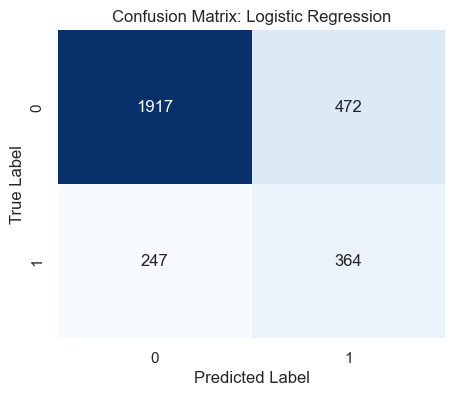

--- ĐÁNH GIÁ MÔ HÌNH: Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      2389
           1       0.57      0.65      0.61       611

    accuracy                           0.83      3000
   macro avg       0.74      0.76      0.75      3000
weighted avg       0.84      0.83      0.83      3000

ROC-AUC Score: 0.8522



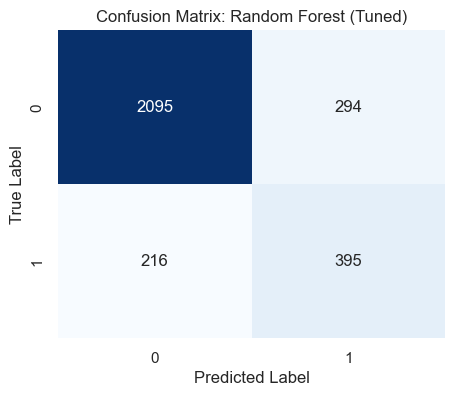

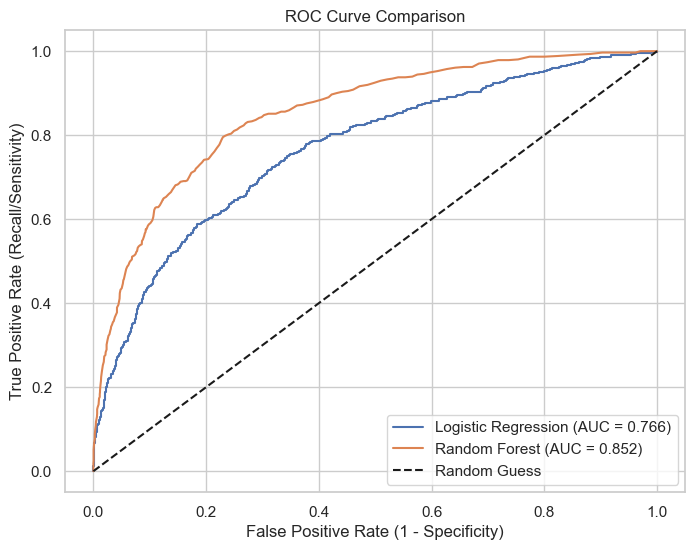

In [10]:
# Hàm in kết quả đánh giá
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"--- ĐÁNH GIÁ MÔ HÌNH: {model_name} ---")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_prob):.4f}\n")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

# Đánh giá Logistic Regression
evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)

# Đánh giá Random Forest (Tối ưu)
evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf, y_prob_rf)

# Vẽ chung ROC Curve để so sánh
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

## 6. Feature Importance & Business Insights (Mức độ quan trọng của đặc trưng & Đề xuất)

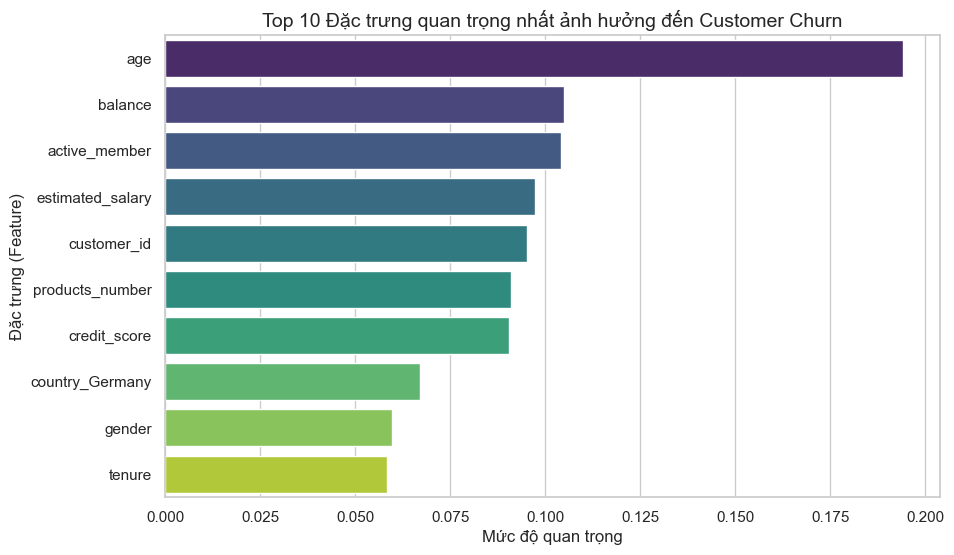

In [11]:
# Trực quan hóa Feature Importance từ Random Forest
importances = best_rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Đặc trưng quan trọng nhất ảnh hưởng đến Customer Churn', fontsize=14)
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng (Feature)')
plt.show()

### 💡 KẾT LUẬN & ĐỀ XUẤT HÀNH ĐỘNG

**1. Phân tích Nguyên nhân (Drivers of Churn):**
* Dựa trên biểu đồ Feature Importance, các yếu tố hàng đầu tác động đến quyết định rời đi là: **Tuổi tác (age), Số dư (balance), Có phải là thành viên hoạt động không (active_member)**.
* Phân tích sâu hơn từ EDA cho thấy: 
	* Khách hàng ở độ tuổi **từ 30 - 40 tuổi** có tỷ lệ rời bỏ cao bất thường.
	* Khách hàng có mức số dư **xung quanh $100k** có tỷ lệ rời bỏ cao bất thường.

**2. Đề xuất Chiến lược (Actionable Recommendations):**
* **Chăm sóc chủ động (Proactive Retention):** Sử dụng mô hình Random Forest để tính toán ra xác suất rời bỏ (Probability) của tệp khách hàng hiện tại. Lọc ra top 10%-20% khách hàng có xác suất rời bỏ cao nhất đẩy sang team Telesale để gọi điện thăm dò mức độ hài lòng.
* **Cá nhân hóa sản phẩm:** Đối với nhóm khách hàng có **[Đặc trưng rủi ro 1]**, ngân hàng nên tung ra các chiến dịch ưu đãi (Voucher giảm phí, nâng hạng thẻ...) hoặc tư vấn cơ cấu lại danh mục sản phẩm (ví dụ: gửi tiết kiệm với lãi suất ưu đãi) để giữ chân họ.